In [7]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # capy-bara/ → finds pipeline
sys.path.insert(0, os.path.abspath("."))           # grid_figs_scripts/ → finds grid_figs_helpers
os.chdir(os.path.abspath("../../.."))              # set cwd to capy-bara/ (matches other notebooks)
import pipeline.metrics as metrics
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gerrychain.grid
import random
from collections import deque
import warnings
random.seed(43)
import seaborn as sns
from grid_figs_helpers import generate_ch_grid, generate_const_grid, generate_clust_grid, generate_isol_grid, generate_kclust_grid, draw_grid_as_checkerboard

In [8]:
M = 1000

In [9]:
def diffuse(G, threshold):
    for node in G.graph.nodes():
        G.graph.nodes[node]["tot_pop"] = G.graph.nodes[node]["x_pop"] + G.graph.nodes[node]["y_pop"]
        G.graph.nodes[node]["rho"] = G.graph.nodes[node]["x_pop"] / G.graph.nodes[node]["tot_pop"]
    graphs = [G.graph.copy()]
    
    core_nodes = [n for n in G.graph.nodes() if G.graph.nodes[n]["rho"] > threshold]
    wetted_nodes = set(core_nodes)
    wetted_x = sum(G.graph.nodes[n]["x_pop"] for n in wetted_nodes)
    wetted_y = sum(G.graph.nodes[n]["y_pop"] for n in wetted_nodes)
    rho = wetted_x / (wetted_x + wetted_y)
    rhos = [rho]
    if not wetted_nodes:
        raise ValueError("No nodes exceed the threshold.")
    if nx.number_connected_components(G.graph) != 1:
        raise ValueError("The graph must be connected for diffusion to occur.")
    while wetted_nodes != set(G.graph.nodes()):
        new_nodes = {nbr for node in wetted_nodes for nbr in G.graph.neighbors(node) if nbr not in wetted_nodes}
        wetted_nodes |= new_nodes
        wetted_x = sum(G.graph.nodes[n]["x_pop"] for n in wetted_nodes)
        wetted_y = sum(G.graph.nodes[n]["y_pop"] for n in wetted_nodes)
        rho = wetted_x / (wetted_x + wetted_y)
        rhos.append(rho)

        for node in wetted_nodes:
            G.graph.nodes[node]["x_pop"] = rho * M
            G.graph.nodes[node]["y_pop"] = (1 - rho) * M
        for node in G.graph.nodes():
            G.graph.nodes[node]["tot_pop"] = G.graph.nodes[node]["x_pop"] + G.graph.nodes[node]["y_pop"]
            G.graph.nodes[node]["rho"] = G.graph.nodes[node]["x_pop"] / G.graph.nodes[node]["tot_pop"]
        graphs.append(G.graph.copy())
    return graphs, rhos

In [40]:
def visualize_diffusion(graphs, rhos):
    rows = len(graphs) // 5
    if len(graphs) % 5 != 0:
        rows += 1
    fig, axes = plt.subplots(rows, 5, figsize=(15, 3 *rows), squeeze = False)
    fig.subplots_adjust(hspace=0.4)
    for i, G in enumerate(graphs):
        ax = axes[i // 5, i % 5]

        nodelist = list(G.nodes())
        checker_cols = [n[0] for n in nodelist]
        checker_rows = [n[1] for n in nodelist]
        width  = max(checker_cols) + 1
        height = max(checker_rows) + 1
        grid = np.zeros((height, width))
        for node in nodelist:
            grid[node[1], node[0]] = G.nodes[node]["rho"]

        ax.imshow(grid, cmap="Blues", vmin=0, vmax=1, origin="lower", interpolation="nearest")     
        ax.set_aspect('auto')
  
        for x in range(width + 1):
            ax.axvline(x - 0.5, color='black', linewidth=0.5)
        for y in range(height + 1):
            ax.axhline(y - 0.5, color='black', linewidth=0.5)

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.5)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        ax.set_title(f"$\\mathbf{{Step\\ {i}}}$\n$\\rho$ of diffused region={rhos[i]:.2f}")
    for j in range(len(graphs), rows * 5):
        axes[j // 5, j % 5].axis("off")

In [41]:
def plot_metrics_over_diffusion(graphs):
    capys = [metrics.half_edge(G, "x_pop", "y_pop") for G in graphs]
    morans = [metrics.moran(G, "x_pop", "tot_pop")["moran_P"] for G in graphs]
    dissimilarities = [metrics.dissimilarity(G, "x_pop", "y_pop", 1) for G in graphs]
    steps = list(range(len(graphs)))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(steps, capys, marker="o", label="Half-edge", color="steelblue")
    ax.plot(steps[:-1], morans[:-1], marker="o", label="Moran's I (P Matrix)", color="darkorange")
    ax.plot(steps, dissimilarities, marker="o", label="Dissimilarity", color="seagreen")
    ax.legend(loc='lower left')

    ax.set_ylim(0, 1)
    ax.set_ylabel("Metric Value")
    ax.set_xlabel("Steps")

    plt.tight_layout()

In [42]:
def generate_2_corner_grid(n,m, M):
    G = gerrychain.grid.Grid((n, m))
    for node in G.graph.nodes:
        G.graph.nodes[node]["x"] = node[0]
        G.graph.nodes[node]["y"] = node[1]
        G.graph.nodes[node]["sum"] = node[0] + node[1]
    for i in range(2):
        for j in range(2):
            G.graph.nodes[(i,j)]["x_pop"] = M
            G.graph.nodes[(i,j)]["y_pop"] = 0
    for node in G.graph.nodes():
        if "x_pop" not in G.graph.nodes[node]:
            G.graph.nodes[node]["x_pop"] = 0
            G.graph.nodes[node]["y_pop"] = M
    return G

In [43]:
def generate_center_grid(n, m, M):
    G = gerrychain.grid.Grid((n, m))
    for node in G.graph.nodes:
        G.graph.nodes[node]["x"] = node[0]
        G.graph.nodes[node]["y"] = node[1]
        G.graph.nodes[node]["sum"] = node[0] + node[1]

    G.graph.nodes[(n//2, m//2)]["x_pop"] = M
    G.graph.nodes[(n//2, m//2)]["y_pop"] = 0

    G.graph.nodes[(n//2 -1, m//2)]["x_pop"] = M
    G.graph.nodes[(n//2 -1, m//2)]["y_pop"] = 0

    G.graph.nodes[(n//2 -1, m//2 -1)]["x_pop"] = M
    G.graph.nodes[(n//2 -1, m//2-1)]["y_pop"] = 0

    G.graph.nodes[(n//2, m//2-1)]["x_pop"] = M
    G.graph.nodes[(n//2, m//2-1)]["y_pop"] = 0

    for node in G.graph.nodes():
        if "x_pop" not in G.graph.nodes[node]:
            G.graph.nodes[node]["x_pop"] = 0
            G.graph.nodes[node]["y_pop"] = M
    return G

In [44]:
def generate_outer_grid(n, m, M):
    G = gerrychain.grid.Grid((n, m))
    for node in G.graph.nodes:
        G.graph.nodes[node]["x"] = node[0]
        G.graph.nodes[node]["y"] = node[1]
        G.graph.nodes[node]["sum"] = node[0] + node[1]
    for i in range(n):
        G.graph.nodes[(i, 0)]["x_pop"] = M
        G.graph.nodes[(i, 0)]["y_pop"] = 0
        G.graph.nodes[(i, m - 1)]["x_pop"] = M
        G.graph.nodes[(i, m - 1)]["y_pop"] = 0
    for j in range(m):
        G.graph.nodes[(0, j)]["x_pop"] = M
        G.graph.nodes[(0, j)]["y_pop"] = 0
        G.graph.nodes[(n - 1, j)]["x_pop"] = M
        G.graph.nodes[(n - 1, j)]["y_pop"] = 0
    for node in G.graph.nodes():
        if "x_pop" not in G.graph.nodes[node]:
            G.graph.nodes[node]["x_pop"] = 0
            G.graph.nodes[node]["y_pop"] = M
    return G

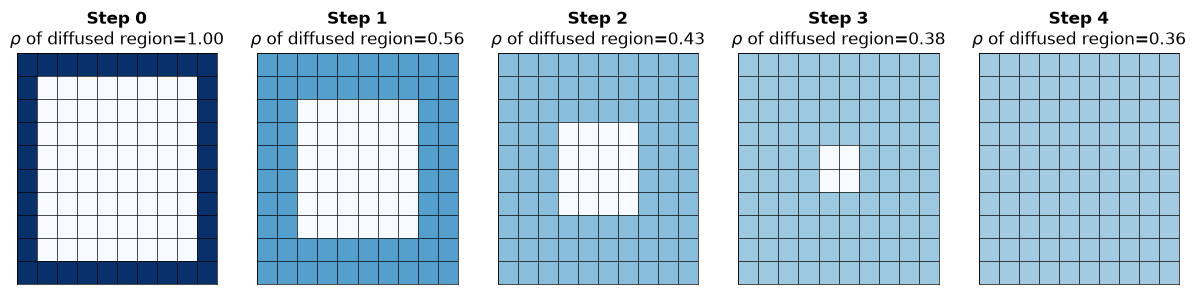

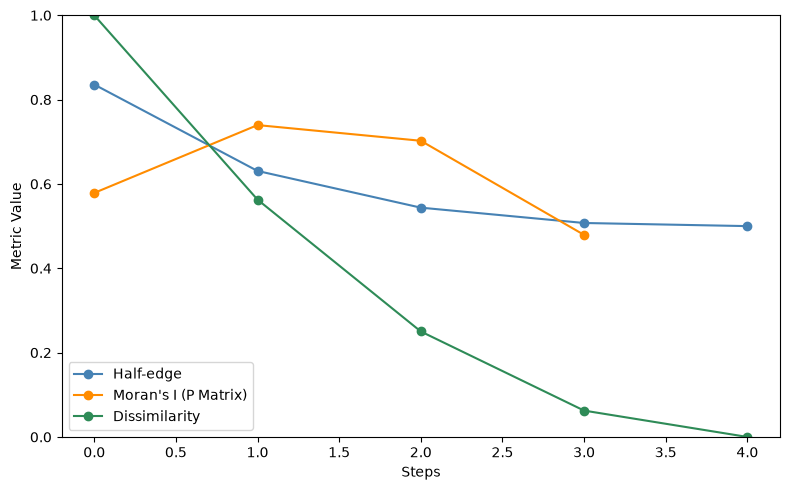

In [45]:
random.seed(53)

G = generate_outer_grid(10, 10, 1000)

graphs, rhos = diffuse(G, threshold=0.3)
visualize_diffusion(graphs, rhos)
plot_metrics_over_diffusion(graphs)